# 02 — Classical baselines A1 and A2 (round R0)

**Owner:** M1 · **Plan:** Phase 4 · **Split:** frozen 70/15/15 (hash `b74d294f…`). Models are selected on **validation**. The test split is not touched until R3.

The two classical approaches bracket the question of temporal order:

| | Model | Temporal order |
|---|---|---|
| **A1** | MFCC summary statistics (mean/std/min/max) + RBF SVM | **discarded**: a clip becomes one vector |
| **A2** | One left-to-right GMM-HMM per word | **modelled**: states must be visited in order |

**Hypothesis.** *tisa* (nine) and *sita* (six) contain the same sounds in a different order. A1 should confuse them more than A2 does. Other near-pairs tracked: *nne/nane*, *tatu/tano*, *saba/sita*.

**How to run.** `RERUN = False` reuses every run already logged in `results/runs/`, so the notebook re-executes in about a minute on Colab. `RERUN = True` retrains everything (about an hour on 8 CPU cores) and overwrites the logs.

In [1]:
import os, sys, subprocess

REPO_URL = "https://github.com/Hassan-Adelani-Luqman/nlp-sequential-modeling-group21.git"
REPO_DIR = "nlp-sequential-modeling-group21"
if os.path.isdir("/kaggle/input") or "google.colab" in sys.modules:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

In [2]:
import json, os, time
import numpy as np, pandas as pd, yaml
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

from src.data import label_names, load_splits
from src.evaluate import (KEY_PAIRS, compute_metrics, cross_fitted_temperature, load_predictions,
                          pair_confusion, plot_confusion_matrix, save_predictions)
from src.features import PRESETS, Standardizer, cached_features, prefix_stats, utterance_cmvn
from src.models.baselines import GMMHMMClassifier, make_a1, tune_a1
from src.paths import CONFIGS_DIR, results_dir
from src.plotting import DEEMPHASIS, INK, INK_SECONDARY, MODEL_COLORS, SERIES, apply_style, blue_cmap, save_figure
from src.utils import build_experiment_table, load_run, log_experiment, set_seed

RERUN = False   # True = retrain every run and overwrite its log; False = reuse runs that are already logged
SEED, MEMBER = 42, "M1"
set_seed(SEED)
apply_style()

NAMES = label_names()
splits = load_splits()
train, val = splits["train"], splits["val"]
SMOKE = os.environ.get("SWN_SMOKE") == "1"
if SMOKE:  # quick end-to-end check on a tiny subsample (use with SWN_OUTPUT_DIR)
    take = lambda df, n: df.groupby("label_id", group_keys=False).head(n).reset_index(drop=True)
    train, val = take(train, 12), take(val, 6)
y_tr, y_val = train.label_id.to_numpy(), val.label_id.to_numpy()
RES = results_dir()
print(f"train {len(train)} clips · val {len(val)} clips · {len(NAMES)} words: {NAMES}")

import platform, sklearn, scipy, librosa, hmmlearn
print(f"environment: Python {platform.python_version()} · numpy {np.__version__} · scipy {scipy.__version__} · "
      f"scikit-learn {sklearn.__version__} · librosa {librosa.__version__} · hmmlearn {hmmlearn.__version__} · "
      f"{os.cpu_count()} CPU cores")

train 2940 clips · val 630 clips · 12 words: ['hapana', 'kumi', 'mbili', 'moja', 'nane', 'ndio', 'nne', 'saba', 'sita', 'tano', 'tatu', 'tisa']
environment: Python 3.14.3 · numpy 2.5.3 · scipy 1.18.1 · scikit-learn 1.9.1 · librosa 1.0.0 · hmmlearn 0.3.3 · 8 CPU cores


In [3]:
SUMMARY = []  # one row per run, shown in the tables below


def run(exp_id, change, rationale, fit_predict, params):
    '''Train and evaluate one configuration on val, or reuse it if already logged (unless RERUN).

    ``fit_predict()`` returns ``(val_probabilities, extra_info)``. Each trained run saves its
    val predictions, its full metrics (per class, key-pair confusions) and one experiment-log record.
    '''
    pred_file = RES / "predictions" / f"{exp_id}_seed{SEED}_val.csv"
    metrics_file = RES / "metrics" / f"{exp_id}_seed{SEED}_val.json"
    record = load_run(exp_id, SEED)
    if record and pred_file.exists() and metrics_file.exists() and not RERUN:
        _, probs = load_predictions(pred_file)
        extra = json.loads(metrics_file.read_text(encoding="utf-8"))["extra"]
        minutes, status = float(record["train_time_min"]), "reused"
    else:
        start = time.time()
        probs, extra = fit_predict()
        minutes, status = (time.time() - start) / 60, "trained"

    m = compute_metrics(y_val, probs, NAMES)
    pairs = {f"{a}/{b}": pair_confusion(y_val, probs.argmax(1), NAMES, a, b) for a, b in KEY_PAIRS}
    if status == "trained":
        save_predictions(exp_id, SEED, "val", val.id, y_val, probs, NAMES)
        metrics_file.parent.mkdir(parents=True, exist_ok=True)
        metrics_file.write_text(json.dumps({"params": params, "extra": extra, "metrics": m, "pair_confusion": pairs},
                                           indent=2), encoding="utf-8")
        log_experiment({"exp_id": exp_id, "seed": SEED, "member": MEMBER, "config_file": "notebooks/02_baselines.ipynb",
                        "change_vs_previous": change, "rationale": rationale,
                        "val_macro_f1": m["macro_f1"], "val_logloss": m["log_loss"], "val_acc": m["accuracy"],
                        "train_time_min": minutes, "gpu": "cpu", "notes": json.dumps({**params, **extra})},
                       overwrite=RERUN)
    SUMMARY.append({"exp_id": exp_id, "change": change, "val_logloss": m["log_loss"], "val_acc": m["accuracy"],
                    "val_macro_f1": m["macro_f1"], "ece": m["ece"], "tisa/sita": pairs["tisa/sita"],
                    "nne/nane": pairs["nne/nane"], "minutes": minutes})
    print(f"{exp_id} [{status}] log loss {m['log_loss']:.3f} · acc {m['accuracy']:.1%} · macro-F1 {m['macro_f1']:.3f}"
          f" · ECE {m['ece']:.3f} · tisa/sita {pairs['tisa/sita']:.1%} · {minutes:.1f} min")
    return {"metrics": m, "probs": probs, "extra": extra, "params": params, "exp_id": exp_id}


def summary(prefix):
    df = pd.DataFrame([r for r in SUMMARY if r["exp_id"].startswith(prefix)]).drop_duplicates("exp_id", keep="last")
    return df.set_index("exp_id")


def show(df):
    display(df.style.format({"val_logloss": "{:.3f}", "val_acc": "{:.1%}", "val_macro_f1": "{:.3f}", "ece": "{:.3f}",
                             "tisa/sita": "{:.1%}", "nne/nane": "{:.1%}", "minutes": "{:.1f}"}))

## A1 — MFCC statistics + SVM

Each clip becomes one fixed-length vector: the mean, std, min and max over time of every MFCC (+ Δ, ΔΔ) channel. Hyperparameters (C, γ) are tuned by **5-fold stratified CV on the training split**, selecting on log loss (the Zindi metric). The chosen model is refitted on all of train and scored once on val.

### Design check: how the SVM produces probabilities
scikit-learn 1.9 deprecates `SVC(probability=True)` and recommends `CalibratedClassifierCV`. Log loss is the official metric, so we measured both on val (C=10, γ=1e-3, the prototype's CV-best setting) before choosing.

In [4]:
calib_file = RES / "metrics" / "a1_svm_probability_methods.csv"
if calib_file.exists() and not RERUN:
    calib = pd.read_csv(calib_file)
else:
    from sklearn.calibration import CalibratedClassifierCV
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVC

    X_tr, X_va = cached_features(train, **PRESETS["mfcc_stats"]), cached_features(val, **PRESETS["mfcc_stats"])
    svc = lambda **kw: SVC(C=10, gamma=1e-3, random_state=SEED, **kw)
    candidates = {"SVC(probability=True): libsvm pairwise Platt": lambda: svc(probability=True),
                  "CalibratedClassifierCV, sigmoid (recommended replacement)":
                      lambda: CalibratedClassifierCV(svc(), method="sigmoid", cv=3, ensemble=False),
                  "CalibratedClassifierCV, temperature":
                      lambda: CalibratedClassifierCV(svc(), method="temperature", cv=3, ensemble=False)}
    rows = []
    for name, make in candidates.items():
        try:
            p = Pipeline([("scale", StandardScaler()), ("clf", make())]).fit(X_tr, y_tr).predict_proba(X_va)
        except (ValueError, TypeError) as err:  # method="temperature" needs scikit-learn >= 1.8
            print(f"skipped {name}: {err}")
            continue
        r = compute_metrics(y_val, p, NAMES)
        rows.append({"method": name, "val_logloss": r["log_loss"], "val_acc": r["accuracy"], "ece": r["ece"]})
    calib = pd.DataFrame(rows)
    calib_file.parent.mkdir(parents=True, exist_ok=True)
    calib.to_csv(calib_file, index=False)
display(calib.style.format({"val_logloss": "{:.3f}", "val_acc": "{:.1%}", "ece": "{:.3f}"}).hide(axis="index"))

method,val_logloss,val_acc,ece
SVC(probability=True): libsvm pairwise Platt,0.880,74.3%,0.102
"CalibratedClassifierCV, sigmoid (recommended replacement)",1.230,73.5%,0.214
"CalibratedClassifierCV, temperature",1.153,73.7%,0.176


**→ Decision:** keep `SVC(probability=True)`. At the same accuracy, it gives clearly lower log loss and better calibration than both replacements. The deprecation warning is silenced in `src/models/baselines.py` with this justification, and `requirements.txt` pins `scikit-learn < 1.11`.

### Runs A1-R0-01 / 02: how much cepstral detail?

In [5]:
def a1_fit_predict(kind, feat):
    def fit_predict():
        X_tr, X_va = cached_features(train, **feat), cached_features(val, **feat)
        search = tune_a1(X_tr, y_tr, kind=kind, seed=SEED)
        best = {k.split("__")[-1]: v for k, v in search.best_params_.items()}
        return search.best_estimator_.predict_proba(X_va), {
            "best_params": best, "cv_logloss": float(-search.best_score_), "n_features": int(X_tr.shape[1])}
    return fit_predict


MFCC13 = {"feature": "mfcc_stats", "crop": "energy", "seconds": 1.5, "n_mfcc": 13}
MFCC40 = dict(PRESETS["mfcc_stats"])  # n_mfcc defaults to 40

a1 = {}
a1["01"] = run("A1-R0-01", "first A1 run: MFCC-13+Δ+ΔΔ statistics (156-d), centred 1.5 s window, RBF SVM",
               "classic compact MFCC set; the order-agnostic reference point",
               a1_fit_predict("svm", MFCC13), {"kind": "svm", "features": MFCC13})
a1["02"] = run("A1-R0-02", "MFCC-40 instead of MFCC-13 (480-d)",
               "finer spectral detail may separate similar vowels (nne/nane, tatu/tano)",
               a1_fit_predict("svm", MFCC40), {"kind": "svm", "features": MFCC40})
A1_FEAT = MFCC40 if a1["02"]["metrics"]["log_loss"] <= a1["01"]["metrics"]["log_loss"] else MFCC13
print("→ features kept:", "MFCC-40" if A1_FEAT is MFCC40 else "MFCC-13")

A1-R0-01 [reused] log loss 0.783 · acc 77.5% · macro-F1 0.774 · ECE 0.074 · tisa/sita 6.7% · 2.3 min
A1-R0-02 [reused] log loss 0.880 · acc 74.3% · macro-F1 0.743 · ECE 0.102 · tisa/sita 7.6% · 6.7 min
→ features kept: MFCC-13


### Run A1-R0-03: is the non-linear kernel needed?

In [6]:
best_svm = min((a1["01"], a1["02"]), key=lambda r: r["metrics"]["log_loss"])
a1["03"] = run("A1-R0-03", "multinomial logistic regression instead of the RBF SVM (same features)",
               "if the clip statistics were linearly separable, a simpler model would do",
               a1_fit_predict("logreg", A1_FEAT), {"kind": "logreg", "features": A1_FEAT})
A1_KIND = "svm" if best_svm["metrics"]["log_loss"] <= a1["03"]["metrics"]["log_loss"] else "logreg"
print("→ classifier kept:", A1_KIND)

A1-R0-03 [reused] log loss 0.725 · acc 77.9% · macro-F1 0.779 · ECE 0.035 · tisa/sita 6.7% · 0.1 min
→ classifier kept: logreg


### Runs A1-R0-04 / 05: does locating the word matter?

In [7]:
NOCROP = {**A1_FEAT, "crop": "none", "seconds": None}
TRIM = {**A1_FEAT, "crop": "trim", "seconds": None}
a1["04"] = run("A1-R0-04", "no crop: statistics over the whole clip (2-62 s)",
               "tests whether the energy window helps, or whether the model copes with silence and noise",
               a1_fit_predict(A1_KIND, NOCROP), {"kind": A1_KIND, "features": NOCROP})
a1["05"] = run("A1-R0-05", "silence trim (top_db 30) instead of the energy window",
               "the other way of locating the word; trimmed clips keep noisy tails",
               a1_fit_predict(A1_KIND, TRIM), {"kind": A1_KIND, "features": TRIM})
A1_BEST = min(a1.values(), key=lambda r: r["metrics"]["log_loss"])
print("→ best A1 run:", A1_BEST["exp_id"])
show(summary("A1"))

A1-R0-04 [reused] log loss 0.821 · acc 73.5% · macro-F1 0.735 · ECE 0.032 · tisa/sita 2.9% · 0.3 min
A1-R0-05 [reused] log loss 0.790 · acc 75.7% · macro-F1 0.757 · ECE 0.050 · tisa/sita 3.8% · 0.3 min
→ best A1 run: A1-R0-03


,change,val_logloss,val_acc,val_macro_f1,ece,tisa/sita,nne/nane,minutes
exp_id,,,,,,,,
A1-R0-01,"first A1 run: MFCC-13+Δ+ΔΔ statistics (156-d), centred 1.5 s window, RBF SVM",0.783,77.5%,0.774,0.074,6.7%,2.9%,2.3
A1-R0-02,MFCC-40 instead of MFCC-13 (480-d),0.880,74.3%,0.743,0.102,7.6%,10.6%,6.7
A1-R0-03,multinomial logistic regression instead of the RBF SVM (same features),0.725,77.9%,0.779,0.035,6.7%,5.8%,0.1
A1-R0-04,no crop: statistics over the whole clip (2-62 s),0.821,73.5%,0.735,0.032,2.9%,3.8%,0.3
A1-R0-05,silence trim (top_db 30) instead of the energy window,0.790,75.7%,0.757,0.050,3.8%,1.9%,0.3


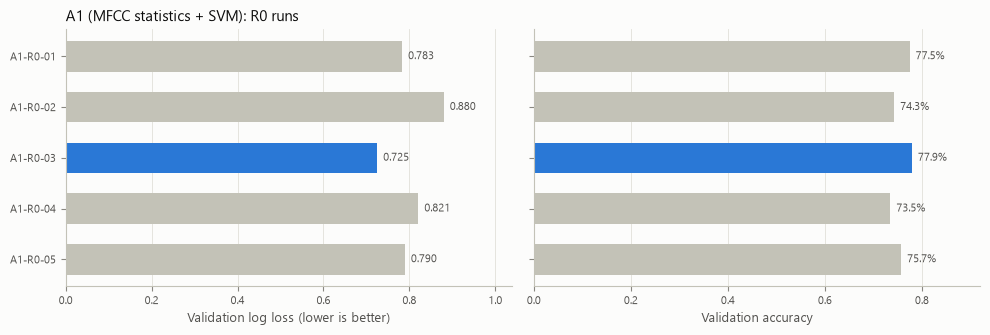

In [8]:
def progression_chart(df, best_id, color, title, name):
    '''Val log loss and accuracy per run; the selected run is highlighted, the others greyed.'''
    fig, axes = plt.subplots(1, 2, figsize=(10, 0.45 * len(df) + 1.2), sharey=True)
    ids = list(df.index)[::-1]
    colors = [color if i == best_id else DEEMPHASIS for i in ids]
    for ax, col, label, fmt in [(axes[0], "val_logloss", "Validation log loss (lower is better)", "{:.3f}"),
                                (axes[1], "val_acc", "Validation accuracy", "{:.1%}")]:
        vals = df.loc[ids, col]
        ax.barh(ids, vals, color=colors, height=0.6)
        for y, v in enumerate(vals):
            ax.text(v, y, "  " + fmt.format(v), va="center", fontsize=8, color=INK_SECONDARY)
        ax.set_xlabel(label)
        ax.grid(axis="y", visible=False)
        ax.set_xlim(0, vals.max() * 1.18)
    axes[0].set_title(title, loc="left")
    fig.tight_layout()
    save_figure(fig, name)
    plt.show()


progression_chart(summary("A1"), A1_BEST["exp_id"], MODEL_COLORS["A1"],
                  "A1 (MFCC statistics + SVM): R0 runs", "a1_r0_progression")

**Observations → next step (A1)**
- **Fewer features did better.** MFCC-13 statistics (156-d) beat MFCC-40 (480-d): log loss 0.783 vs 0.880, accuracy 77.5% vs 74.3%. With 245 training clips per word, the larger vector adds noisy dimensions faster than useful information.
- **A linear model is enough.** Strongly regularised logistic regression (C = 0.1) beats the RBF SVM on the same features: log loss 0.725 vs 0.783, with better calibration (ECE 0.035 vs 0.074). What limits A1 is the order-free representation, not the classifier.
- **Locating the word helps.** The centred energy window (log loss 0.725) beats statistics over the whole clip (0.821) and silence trimming (0.790).
- **Where A1 fails.** Validation accuracy is 77.9%.
  - The largest confusions are *mbili*→*ndio* (9 of 53 *mbili* clips), *tano*→*tatu* and *tisa*→*sita* (5 clips each).
  - *tano* and *tatu* share their first syllable. *tisa* and *sita* contain the same sounds. *mbili* and *ndio* both begin with a prenasalised stop (*mb-*, *nd-*), followed by /i/.
  - A summary of the frames keeps which sounds occur, but not their order.
- **→ Next:** A1 is frozen as A1-R0-03 (`configs/a1_best.yaml`). Temperature scaling is tested for every model in R2.

## A2 — GMM-HMM per word

One left-to-right HMM per word on MFCC-13 + Δ + ΔΔ frames (39-d), with diagonal-covariance Gaussian mixtures per state and a flat-start initialisation (`src/models/baselines.py`). A clip goes to the word whose model gives the highest per-frame log-likelihood. Probabilities are a softmax over those scores with a temperature, **cross-fitted on val**, so the val log loss is not optimistic.

The Phase 1 profiling showed that silence-trimmed clips keep long noisy tails (median 1.9 s, up to 62 s). So the preprocessing is fixed first, one factor at a time, with 5 states × 2 Gaussians. Then the model size is tuned.

In [9]:
def a2_sequences(feat, cmvn):
    tr, va = list(cached_features(train, **feat)), list(cached_features(val, **feat))  # energy crop -> (N,T,C) array
    if cmvn:
        tr, va = utterance_cmvn(tr), utterance_cmvn(va)
    scaler = Standardizer().fit(tr)
    return scaler.transform(tr), scaler.transform(va)


def a2_fit_predict(feat, cmvn, n_states, n_mix):
    def fit_predict():
        s_tr, s_va = a2_sequences(feat, cmvn)
        clf = GMMHMMClassifier(n_states=n_states, n_mix=n_mix, seed=SEED).fit(s_tr, y_tr)
        probs, temperature = cross_fitted_temperature(clf.scores(s_va), y_val, seed=SEED)
        return probs, {"temperature": temperature, "median_frames": float(np.median([len(s) for s in s_va]))}
    return fit_predict


def a2_params(feat, cmvn, n_states, n_mix):
    return {"features": feat, "cmvn": cmvn, "n_states": n_states, "n_mix": n_mix}


TRIM30 = dict(PRESETS["mfcc13_trim"])
TRIM20 = {**TRIM30, "top_db": 20}
ENERGY = {"feature": "mfcc", "crop": "energy", "seconds": 1.5, "n_mfcc": 13}

a2 = {}
a2["01"] = run("A2-R0-01", "first A2 run: 5 states x 2 Gaussians, silence trim (top_db 30), global standardisation",
               "classic left-to-right word HMM; the order-aware classical reference point",
               a2_fit_predict(TRIM30, False, 5, 2), a2_params(TRIM30, False, 5, 2))
a2["02"] = run("A2-R0-02", "+ per-utterance CMVN",
               "~300 speakers on different phones: remove each clip's channel offset, as in classic ASR",
               a2_fit_predict(TRIM30, True, 5, 2), a2_params(TRIM30, True, 5, 2))
CMVN = a2["02"]["metrics"]["log_loss"] < a2["01"]["metrics"]["log_loss"]
print("→ keep CMVN:", CMVN)

A2-R0-01 [reused] log loss 1.650 · acc 53.2% · macro-F1 0.533 · ECE 0.084 · tisa/sita 7.6% · 3.3 min
A2-R0-02 [reused] log loss 0.931 · acc 75.6% · macro-F1 0.759 · ECE 0.088 · tisa/sita 6.7% · 3.6 min
→ keep CMVN: True


In [10]:
a2["03"] = run("A2-R0-03", "centred 1.5 s energy window instead of silence trim",
               "trimmed sequences keep long noisy tails; a fixed window around the word removes them",
               a2_fit_predict(ENERGY, CMVN, 5, 2), a2_params(ENERGY, CMVN, 5, 2))
a2["04"] = run("A2-R0-04", "stricter silence trim (top_db 20) instead of top_db 30",
               "cut more of the noisy tails while keeping each word's natural length",
               a2_fit_predict(TRIM20, CMVN, 5, 2), a2_params(TRIM20, CMVN, 5, 2))
prep_runs = [a2[k] for k in ("01", "02", "03", "04")]
A2_PREP = min(prep_runs, key=lambda r: r["metrics"]["log_loss"])
A2_FEAT, A2_CMVN = A2_PREP["params"]["features"], A2_PREP["params"]["cmvn"]
print(f"→ preprocessing kept: {A2_PREP['exp_id']} ({A2_FEAT['crop']}, cmvn={A2_CMVN})")

A2-R0-03 [reused] log loss 0.380 · acc 91.1% · macro-F1 0.911 · ECE 0.033 · tisa/sita 3.8% · 3.5 min
A2-R0-04 [reused] log loss 0.612 · acc 81.0% · macro-F1 0.811 · ECE 0.038 · tisa/sita 1.9% · 3.0 min
→ preprocessing kept: A2-R0-03 (energy, cmvn=True)


### Runs A2-R0-05 … 12: model size (states × Gaussians per state) on the chosen preprocessing

In [11]:
grid = {(5, 2): A2_PREP}   # 5 x 2 on this preprocessing is already done
n = 5
for n_states in (3, 5, 8):
    for n_mix in (1, 2, 4):
        if (n_states, n_mix) in grid:
            continue
        exp_id = f"A2-R0-{n:02d}"
        n += 1
        grid[(n_states, n_mix)] = run(exp_id, f"{n_states} states x {n_mix} Gaussians per state",
                                      "grid over HMM capacity on the chosen preprocessing",
                                      a2_fit_predict(A2_FEAT, A2_CMVN, n_states, n_mix),
                                      a2_params(A2_FEAT, A2_CMVN, n_states, n_mix))
        a2[exp_id[-2:]] = grid[(n_states, n_mix)]
A2_BEST = min(a2.values(), key=lambda r: r["metrics"]["log_loss"])
print("→ best A2 run:", A2_BEST["exp_id"], A2_BEST["params"])
show(summary("A2"))

A2-R0-05 [reused] log loss 1.729 · acc 47.5% · macro-F1 0.484 · ECE 0.091 · tisa/sita 22.9% · 1.3 min


A2-R0-06 [reused] log loss 0.743 · acc 81.0% · macro-F1 0.811 · ECE 0.055 · tisa/sita 1.0% · 2.3 min
A2-R0-07 [reused] log loss 0.461 · acc 89.4% · macro-F1 0.896 · ECE 0.050 · tisa/sita 0.0% · 2.9 min


A2-R0-08 [reused] log loss 1.057 · acc 73.0% · macro-F1 0.738 · ECE 0.105 · tisa/sita 8.6% · 2.4 min
A2-R0-09 [reused] log loss 0.272 · acc 94.3% · macro-F1 0.943 · ECE 0.029 · tisa/sita 0.0% · 3.5 min


A2-R0-10 [reused] log loss 0.373 · acc 90.0% · macro-F1 0.900 · ECE 0.044 · tisa/sita 2.9% · 1.7 min
A2-R0-11 [reused] log loss 0.304 · acc 93.5% · macro-F1 0.935 · ECE 0.031 · tisa/sita 1.0% · 3.0 min
A2-R0-12 [reused] log loss 0.220 · acc 95.1% · macro-F1 0.951 · ECE 0.033 · tisa/sita 0.0% · 5.8 min
→ best A2 run: A2-R0-12 {'features': {'feature': 'mfcc', 'crop': 'energy', 'seconds': 1.5, 'n_mfcc': 13}, 'cmvn': True, 'n_states': 8, 'n_mix': 4}


,change,val_logloss,val_acc,val_macro_f1,ece,tisa/sita,nne/nane,minutes
exp_id,,,,,,,,
A2-R0-01,"first A2 run: 5 states x 2 Gaussians, silence trim (top_db 30), global standardisation",1.650,53.2%,0.533,0.084,7.6%,3.8%,3.3
A2-R0-02,+ per-utterance CMVN,0.931,75.6%,0.759,0.088,6.7%,2.9%,3.6
A2-R0-03,centred 1.5 s energy window instead of silence trim,0.380,91.1%,0.911,0.033,3.8%,0.0%,3.5
A2-R0-04,stricter silence trim (top_db 20) instead of top_db 30,0.612,81.0%,0.811,0.038,1.9%,1.9%,3.0
A2-R0-05,3 states x 1 Gaussians per state,1.729,47.5%,0.484,0.091,22.9%,18.3%,1.3
A2-R0-06,3 states x 2 Gaussians per state,0.743,81.0%,0.811,0.055,1.0%,2.9%,2.3
A2-R0-07,3 states x 4 Gaussians per state,0.461,89.4%,0.896,0.050,0.0%,1.9%,2.9
A2-R0-08,5 states x 1 Gaussians per state,1.057,73.0%,0.738,0.105,8.6%,1.9%,2.4
A2-R0-09,5 states x 4 Gaussians per state,0.272,94.3%,0.943,0.029,0.0%,0.0%,3.5


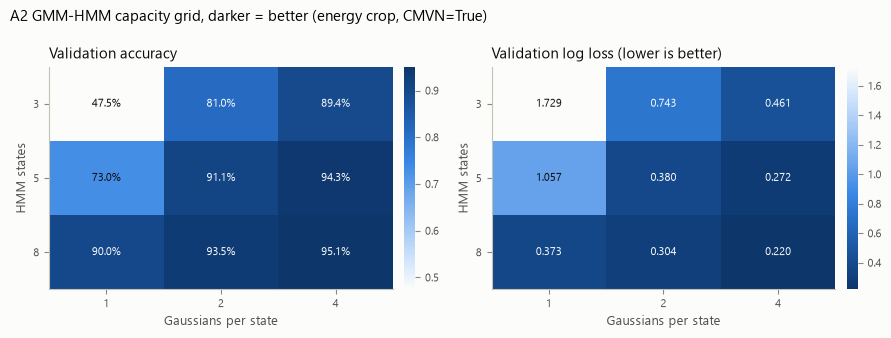

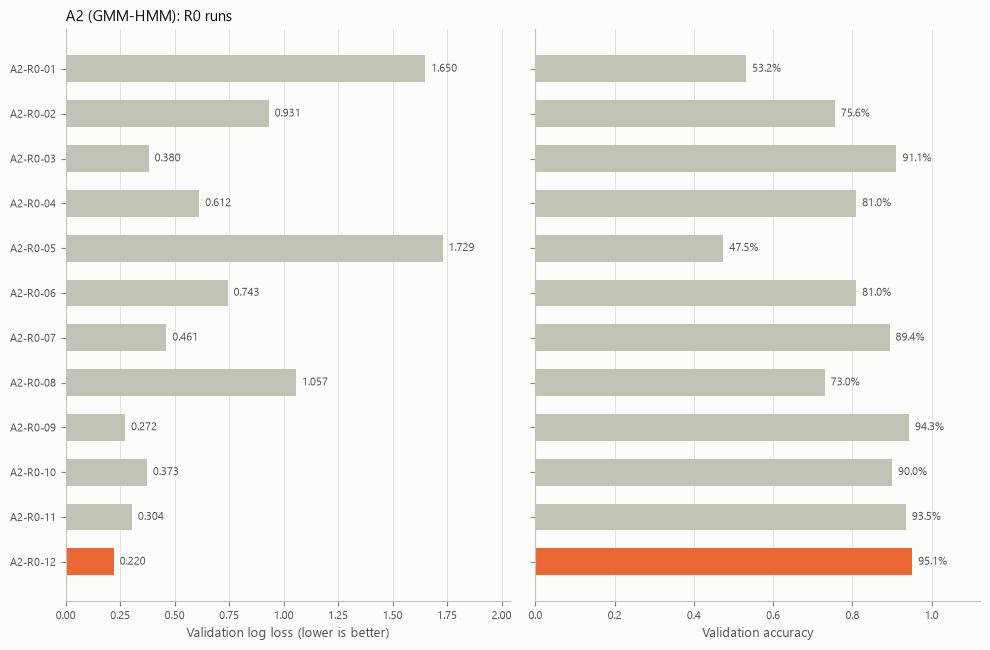

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
states, mixes = (3, 5, 8), (1, 2, 4)
for ax, key, title, fmt in [(axes[0], "accuracy", "Validation accuracy", "{:.1%}"),
                            (axes[1], "log_loss", "Validation log loss (lower is better)", "{:.3f}")]:
    values = np.array([[grid[(s, k)]["metrics"][key] for k in mixes] for s in states])
    higher_is_better = key == "accuracy"
    cmap = blue_cmap() if higher_is_better else blue_cmap().reversed()  # darker = better in both panels
    im = ax.imshow(values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(3), [f"{k}" for k in mixes])
    ax.set_yticks(range(3), [f"{s}" for s in states])
    ax.set_xlabel("Gaussians per state")
    ax.set_ylabel("HMM states")
    ax.set_title(title, loc="left")
    ax.grid(False)
    for i in range(3):
        for j in range(3):
            v = values[i, j]
            level = (v - values.min()) / (np.ptp(values) or 1)
            dark = level > 0.55 if higher_is_better else level < 0.45
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8, color="#fcfcfb" if dark else INK)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03).outline.set_visible(False)
fig.suptitle(f"A2 GMM-HMM capacity grid, darker = better ({A2_FEAT['crop']} crop, CMVN={A2_CMVN})", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save_figure(fig, "a2_r0_capacity_grid")
plt.show()

progression_chart(summary("A2"), A2_BEST["exp_id"], MODEL_COLORS["A2"], "A2 (GMM-HMM): R0 runs", "a2_r0_progression")

**Observations → next step (A2)**
- **Preprocessing mattered more than model size.** The first run reached 53.2% (silence trim, global standardisation).
  - Per-utterance CMVN raised accuracy to 75.6% (log loss 1.650 → 0.931). It removes each recording's channel offset: about 300 speakers on different phones.
  - Replacing the silence trim with the centred 1.5 s energy window raised it to 91.1% (log loss 0.380). Trimmed clips keep long noisy tails, which the HMM had to model as if they were speech.
  - A stricter trim (top_db 20) only reached 81.0%.
- **More capacity helped throughout.** Accuracy rises with both the number of states and the Gaussians per state. The best model has 8 states × 4 Gaussians: 95.1% accuracy, log loss 0.220, ECE 0.033.
- **Order resolution separates the anagram pair.** With one Gaussian per state, *tisa/sita* confusion falls from 22.9% (3 states) to 8.6% (5) to 2.9% (8). The model needs enough states to represent the order of the sounds.
  - Richer mixtures also remove it: 3 states × 4 Gaussians reaches 0%. This is likely because the Δ/ΔΔ features already encode local ordering over about 90 ms, which a flexible mixture can use.
  - These rates rest on 105 clips, so one clip is about one percentage point.
- **→ Next:** the best configuration is at the corner of the grid (the largest states and mixtures tried), so A2 may not have peaked. R2 (Day 4) should extend the grid, e.g. 10–12 states and 6–8 Gaussians, before A2 is frozen for the final comparison.

## A1 vs A2: does modelling order help?
Best run of each approach, both scored on the same 630 validation clips.

,run,val log loss,val accuracy,val macro-F1,ECE,tisa/sita confusion,nne/nane confusion,tatu/tano confusion,saba/sita confusion
A1,A1-R0-03,0.725027,0.779365,0.778867,0.035461,0.066667,0.057692,0.084906,0.0
A2,A2-R0-12,0.219968,0.950794,0.950952,0.032759,0.0,0.019231,0.037736,0.0


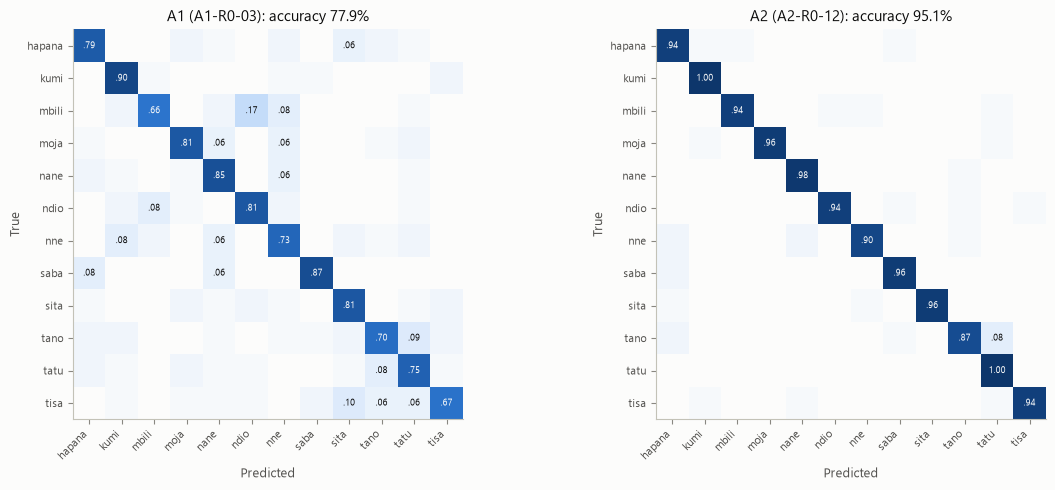

In [13]:
best = {"A1": A1_BEST, "A2": A2_BEST}
comparison = pd.DataFrame({
    name: {"run": r["exp_id"], "val log loss": r["metrics"]["log_loss"], "val accuracy": r["metrics"]["accuracy"],
           "val macro-F1": r["metrics"]["macro_f1"], "ECE": r["metrics"]["ece"],
           **{f"{a}/{b} confusion": pair_confusion(y_val, r["probs"].argmax(1), NAMES, a, b) for a, b in KEY_PAIRS}}
    for name, r in best.items()}).T
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, r) in zip(axes, best.items()):
    plot_confusion_matrix(y_val, r["probs"].argmax(1), NAMES, ax=ax, colorbar=False,
                          title=f"{name} ({r['exp_id']}): accuracy {r['metrics']['accuracy']:.1%}")
fig.tight_layout()
save_figure(fig, "r0_confusion_a1_vs_a2")
plt.show()

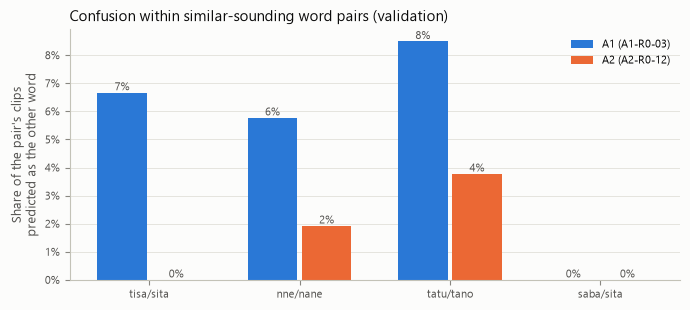

In [14]:
pairs = [f"{a}/{b}" for a, b in KEY_PAIRS]
fig, ax = plt.subplots(figsize=(7, 3.2))
width = 0.36
for i, (name, r) in enumerate(best.items()):
    vals = [pair_confusion(y_val, r["probs"].argmax(1), NAMES, a, b) for a, b in KEY_PAIRS]
    xs = np.arange(len(pairs)) + (i - 0.5) * width
    ax.bar(xs, vals, width=width - 0.03, color=MODEL_COLORS[name], label=f"{name} ({r['exp_id']})")
    for x, v in zip(xs, vals):
        ax.text(x, v, f"{v:.0%}", ha="center", va="bottom", fontsize=8, color=INK_SECONDARY)
ax.set_xticks(range(len(pairs)), pairs)
ax.set_ylabel("Share of the pair's clips\npredicted as the other word")
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
ax.set_title("Confusion within similar-sounding word pairs (validation)", loc="left")
fig.tight_layout()
save_figure(fig, "r0_key_pair_confusion")
plt.show()

**Observations → next step (A1 vs A2)**
- **Modelling order cuts the error rate by about three quarters.** On the same MFCC-13 + Δ + ΔΔ frames from the same window, A2 reaches 95.1% accuracy (log loss 0.220) against A1's 77.9% (0.725). The error rate falls from 22.1% to 4.9%.
  - Part of the gain comes from per-utterance CMVN, which only A2 uses. The statistics representation would lose its mean and std features to it.
  - So this is order modelling *plus* normalisation, not order alone. The within-A2 results above isolate the effect of order more cleanly.
- **The sound-alike pairs follow the hypothesis.** A2 removes the *tisa/sita* confusion entirely (6.7% → 0%), and cuts *nne/nane* (5.8% → 1.9%) and *tatu/tano* (8.5% → 3.8%).
  - A2's only repeated error is *tano*→*tatu* (4 clips): the same first syllable, and a short, similar second one.
- **Caveats.**
  - Each pair has about 105 validation clips, so one clip is about one percentage point, and differences of a few clips are within noise. R3 tests the differences with McNemar's test and bootstrap intervals.
  - The best of 17 configurations was chosen on this same validation split, so these validation scores are slightly optimistic. The untouched test split gives the unbiased numbers in R3.
- **→ Next:** A2 sets a demanding bar for the neural sequence models (Phase 5): 95.1% accuracy and log loss 0.220 on validation. The question for A3–A5 is not only whether they beat it, but where their errors differ.

## EDA analysis 8: how early is a word recognisable?
For the Phase 3 EDA we train the best A1 configuration on only the **first 25 / 50 / 75 / 100 %** of each spoken word. The word is located by the centred energy window, with its surrounding silence trimmed. Words that share an onset (*tatu*, *tano*, *tisa* all start with "t") should need more of the word before they can be told apart.

In [15]:
from joblib import Parallel, delayed

FRACTIONS = [0.25, 0.5, 0.75, 1.0]
early_file = RES / "metrics" / "eda8_how_early.csv"
if early_file.exists() and not RERUN:
    early = pd.read_csv(early_file)
else:
    kind, hp = A1_BEST["params"]["kind"], A1_BEST["extra"]["best_params"]
    n_mfcc = A1_BEST["params"]["features"].get("n_mfcc", 40)
    rows = []
    for f in FRACTIONS:
        feats = lambda df: np.stack(Parallel(n_jobs=-1)(delayed(prefix_stats)(p, f, n_mfcc=n_mfcc) for p in df.path))
        clf = make_a1(kind, SEED).set_params(**{f"clf__{k}": v for k, v in hp.items()}).fit(feats(train), y_tr)
        pred = clf.predict(feats(val))
        rows.append({"fraction": f, "word": "all words", "accuracy": float((pred == y_val).mean())})
        rows += [{"fraction": f, "word": w, "accuracy": float((pred[y_val == c] == c).mean())} for c, w in enumerate(NAMES)]
        print(f"first {f:.0%} of the word: accuracy {rows[-len(NAMES) - 1]['accuracy']:.1%}")
    early = pd.DataFrame(rows)
    early_file.parent.mkdir(parents=True, exist_ok=True)
    early.to_csv(early_file, index=False)

wide = early.pivot(index="word", columns="fraction", values="accuracy")
display(wide.style.format("{:.0%}"))

fraction,0.250000,0.500000,0.750000,1.000000
word,,,,
all words,49%,72%,80%,80%
hapana,60%,81%,85%,79%
kumi,67%,83%,96%,96%
mbili,47%,68%,85%,77%
moja,52%,79%,83%,81%
nane,60%,83%,92%,88%
ndio,42%,58%,81%,83%
nne,46%,67%,69%,65%
saba,58%,77%,81%,88%


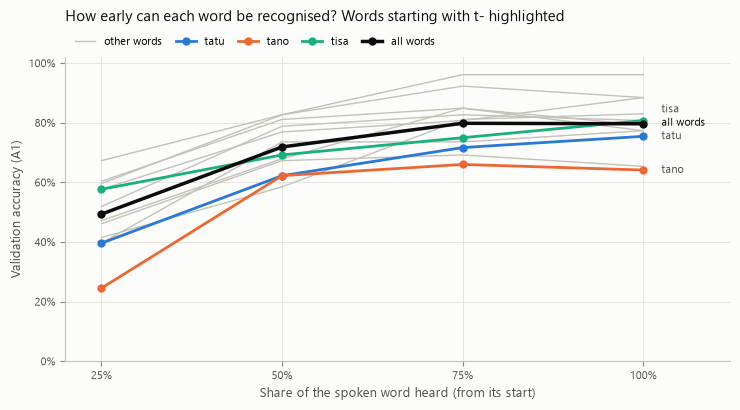

In [16]:
def spread(values, min_gap=0.045):
    # nudge end-of-line label positions apart so the labels never overlap
    order = sorted(range(len(values)), key=lambda i: values[i])
    pos = list(values)
    for a, b in zip(order, order[1:]):
        pos[b] = max(pos[b], pos[a] + min_gap)
    return pos


fig, ax = plt.subplots(figsize=(7.5, 4.2))
highlight = {"tatu": SERIES[0], "tano": SERIES[1], "tisa": SERIES[2]}
for w in NAMES:
    if w not in highlight:
        ax.plot(FRACTIONS, wide.loc[w, FRACTIONS], color=DEEMPHASIS, lw=1, zorder=1)
ax.plot([], [], color=DEEMPHASIS, lw=1, label="other words")
for w, c in highlight.items():
    ax.plot(FRACTIONS, wide.loc[w, FRACTIONS], color=c, marker="o", zorder=3, label=w)
ax.plot(FRACTIONS, wide.loc["all words", FRACTIONS], color=INK, marker="o", lw=2.5, zorder=4, label="all words")

labelled = list(highlight) + ["all words"]
for w, y in zip(labelled, spread([wide.loc[w, 1.0] for w in labelled])):
    ax.annotate(w, (FRACTIONS[-1], wide.loc[w, 1.0]), xytext=(FRACTIONS[-1] + 0.025, y), textcoords="data",
                va="center", fontsize=8, color=INK if w == "all words" else INK_SECONDARY)
ax.set_xticks(FRACTIONS, [f"{f:.0%}" for f in FRACTIONS])
ax.set_xlim(0.2, 1.12)
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Share of the spoken word heard (from its start)")
ax.set_ylabel("Validation accuracy (A1)")
ax.set_title("How early can each word be recognised? Words starting with t- highlighted", loc="left", pad=26)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=5, handlelength=1.8, columnspacing=1.2)
fig.tight_layout()
save_figure(fig, "eda8_how_early")
plt.show()

**Observations → decision (EDA 8)**
- **Most of the evidence arrives in the first half of the word.** A1's accuracy rises from 49.4% (first quarter) to 71.9% (first half) and 79.8% (three quarters). Overall, hearing the last quarter adds nothing (79.7%).
- **Words that share their first sounds need the rest of the word.**
  - After the first quarter, *tano* is the lowest of all 12 words (24.5%). *tatu* and *sita* tie next (39.6%). Each shares its first consonant with another word: *ta-no* / *ta-tu*, and *si-ta* / *sa-ba*.
  - *tano* and *tatu* both jump to 62.3% by the half-way point, once their second syllable starts.
  - *tisa* is already at 57.7% after one quarter: its first vowel (/i/) differs from *ta-*.
- **→ Decision:** the evidence that separates the confusable words sits in the middle of the word. The models therefore need the whole utterance and its order. This supports the centred window over the whole word (rather than onset-only truncation) and the sequence models A2–A5. *(Input for the Phase 3 EDA, M3.)*

## Save the selected configurations and the experiment table

In [17]:
def best_config(approach, r):
    return {"approach": approach, "exp_id": r["exp_id"], "selected_by": "lowest validation log loss in round R0",
            "params": r["params"], "extra": r["extra"],
            "val": {k: round(r["metrics"][k], 4) for k in ("log_loss", "accuracy", "macro_f1", "ece")}}


for approach, r in best.items():
    path = (RES if SMOKE else CONFIGS_DIR) / f"{approach.lower()}_best.yaml"  # smoke runs never touch configs/
    path.write_text(yaml.safe_dump(best_config(approach, r), sort_keys=False), encoding="utf-8")
    print("wrote", path)

table = build_experiment_table()
display(table[table.exp_id.str.match(r"A[12]-R0")][["exp_id", "change_vs_previous", "val_logloss", "val_acc",
                                                     "val_macro_f1", "train_time_min"]])

wrote C:\Users\Luqma\dev\projects\coursework\nlp-sequential-modeling-group21\configs\a1_best.yaml
wrote C:\Users\Luqma\dev\projects\coursework\nlp-sequential-modeling-group21\configs\a2_best.yaml


,exp_id,change_vs_previous,val_logloss,val_acc,val_macro_f1,train_time_min
0,A1-R0-01,"first A1 run: MFCC-13+Δ+ΔΔ statistics (156-d),...",0.7830,0.7746,0.7743,2.2702
1,A1-R0-02,MFCC-40 instead of MFCC-13 (480-d),0.8801,0.7429,0.7430,6.7290
2,A1-R0-03,multinomial logistic regression instead of the...,0.7250,0.7794,0.7789,0.0520
3,A1-R0-04,no crop: statistics over the whole clip (2-62 s),0.8208,0.7349,0.7348,0.2584
4,A1-R0-05,silence trim (top_db 30) instead of the energy...,0.7895,0.7571,0.7575,0.2597
5,A2-R0-01,"first A2 run: 5 states x 2 Gaussians, silence ...",1.6495,0.5317,0.5330,3.3038
6,A2-R0-02,+ per-utterance CMVN,0.9313,0.7556,0.7591,3.5648
7,A2-R0-03,centred 1.5 s energy window instead of silence...,0.3804,0.9111,0.9114,3.4897
8,A2-R0-04,stricter silence trim (top_db 20) instead of t...,0.6124,0.8095,0.8107,3.0316
9,A2-R0-05,3 states x 1 Gaussians per state,1.7290,0.4746,0.4839,1.2678
